## Del 1 – Grundläggande analys och statistik

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/health_study_dataset.csv")

df.head(3)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


In [2]:
na_counts = df.isna().sum()
print("\nSaknade värden per kolumn:")
print(na_counts)


Saknade värden per kolumn:
id             0
age            0
sex            0
height         0
weight         0
systolic_bp    0
cholesterol    0
smoker         0
disease        0
dtype: int64


In [3]:
df.duplicated().any()

np.False_

### Räknar ut medel, median, min och max :

In [4]:
columns = ["age", "weight", "height", "systolic_bp", "cholesterol"].copy()
for column in columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")


In [5]:
df[columns].dtypes

age              int64
weight         float64
height         float64
systolic_bp    float64
cholesterol    float64
dtype: object

In [6]:
summary = df[columns].agg(["mean", "median", "min", "max"])
print(summary)

             age   weight     height  systolic_bp  cholesterol
mean    49.42625   73.413  171.84925   149.178625      4.92915
median  50.00000   73.200  171.35000   149.400000      4.97000
min     18.00000   33.700  144.40000   106.800000      2.50000
max     90.00000  114.400  200.40000   185.900000      7.88000


### 3 grafer till

In [7]:
plt.rcParams["figure.figsize"] = (8,5)   # sätter lite standardvärden för alla grafer, storlek, skärpan på grafer, osv. 
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120
np.set_printoptions(precision=3)
pd.set_option("display.precision", 3)

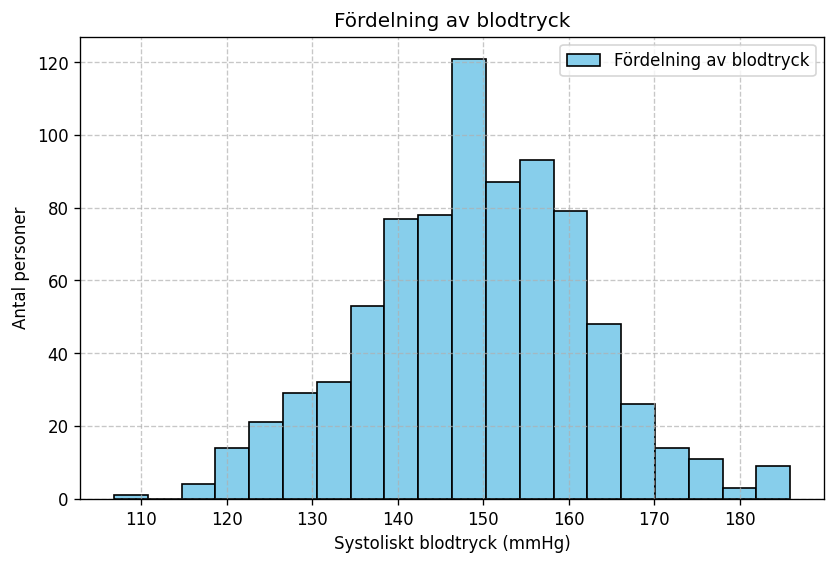

In [8]:
fig, ax = plt.subplots()

ax.hist(df["systolic_bp"], bins =20, label= "Fördelning av blodtryck", color="skyblue", edgecolor="black")
ax.set_title("Fördelning av blodtryck")
ax.set_xlabel("Systoliskt blodtryck (mmHg)")
ax.set_ylabel("Antal personer")
ax.grid(True, linestyle="--", alpha=0.7)
ax.legend()
plt.show()

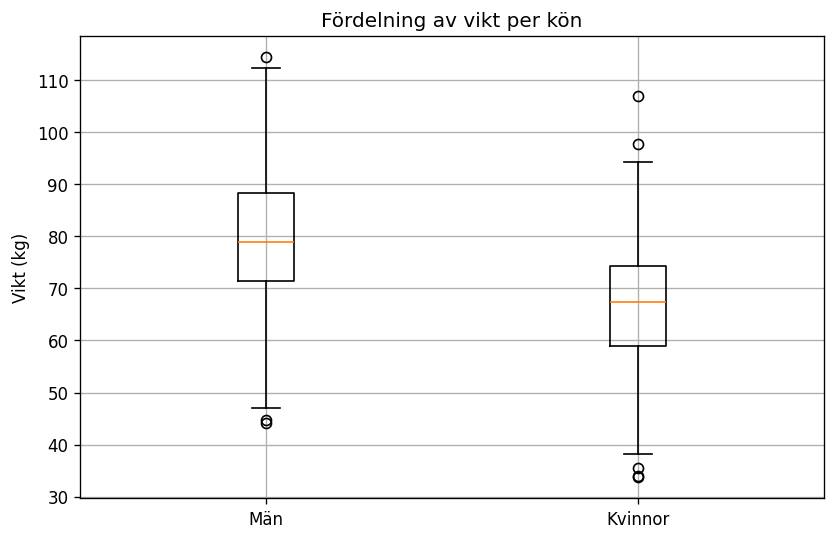

In [9]:
fig, ax = plt.subplots()

ax.boxplot([df.loc[df["sex"] == "M", "weight"],
            df.loc[df["sex"] == "F", "weight"]],
            tick_labels = ["Män", "Kvinnor"])

ax.set_title("Fördelning av vikt per kön")
ax.set_ylabel("Vikt (kg)")
plt.show()

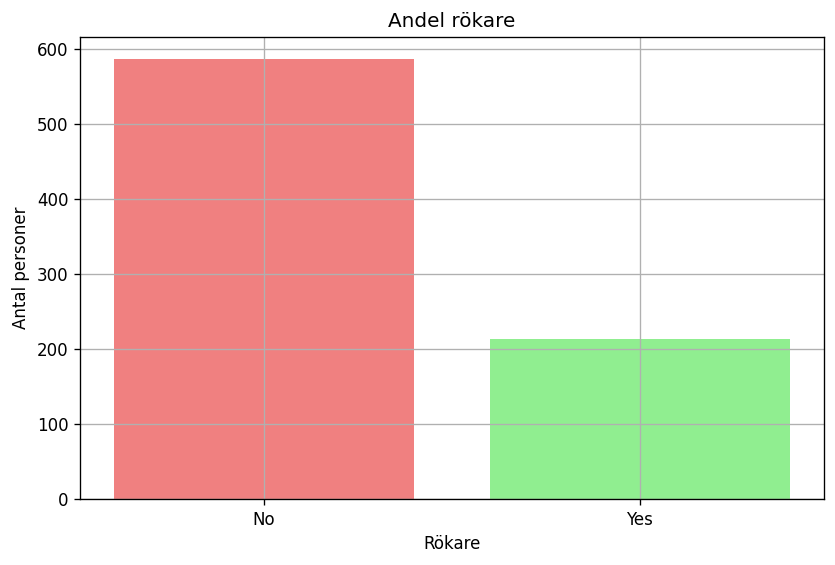

In [10]:
smoker_counts = df["smoker"].value_counts()

fig, ax = plt.subplots()

ax.bar(smoker_counts.index, smoker_counts.values, color=["lightcoral", "lightgreen"])
ax.set_title("Andel rökare")
ax.set_xlabel("Rökare")
ax.set_ylabel("Antal personer")
plt.show()

### Andel personer som har sjukdom

In [11]:
andel_sjuka = df["disease"].mean()
print("Andel sjuka i datasetet: ", andel_sjuka)

Andel sjuka i datasetet:  0.05875


In [12]:
# alltså cirka 6% har sjukdomen

In [13]:
np.random.seed(42)
simulated= np.random.choice([0, 1], size=1000, p=[1-andel_sjuka, andel_sjuka])

simulated_rate = simulated.mean()
print("Andelen sjuka i simuleringen:", simulated_rate)

Andelen sjuka i simuleringen: 0.056


In [14]:
print(f"Verklig andel:      {andel_sjuka*100:.1f}%")
print(f"Simulerad andel:    { simulated_rate*100:.1f}%   ")

Verklig andel:      5.9%
Simulerad andel:    5.6%   


In [15]:
# inte stor skillnad alls mellan dessa

### Konfidensintervall för medelvärdet av systolic_bp

In [16]:
# Jag kommer att använda mig av normalapproximation som känns lite lättare:

In [17]:
x = df["systolic_bp"].to_numpy()
n = len(x)
mean = x.mean()
std = x.std(ddof=1)
se = std / np.sqrt(n)
z = 1.96

ci_low = mean - z*se
ci_high = mean + z*se

print(f"Medel:  {mean:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")

Medel:  149.18
95% CI: [148.29, 150.07]


In [18]:
# Det visades att sanna medelvärde befinner sig i intervallet jag fick fram. Det kan vi vara 95% säkra på.

### Hypotesprövning 
Testar om rökare har högre medel-blodtryck än icke rökare.

In [19]:
if df["smoker"].dtype == "0":
    df["smoker"] = df["smoker"].map({"Yes": 1, "No": 0}) # det här funkar inte riktigt för mig, testar annat istället:

if df["smoker"].dtype == object :
    df["smoker"] = (
        df["smoker"].astype(str).str.strip()
        .map({"Yes": 1, "No": 0, "1":1, "0":0})
        .astype(int)
    )

bp_smoke = df.loc[df["smoker"] == 1, "systolic_bp"].to_numpy()
bp_not_smoke = df.loc[df["smoker"] == 0, "systolic_bp"].to_numpy()

mean_smoke = bp_smoke.mean()
mean_not_smoke = bp_not_smoke.mean()
obs_diff = mean_smoke - mean_not_smoke

n1 = bp_smoke.size
n2 = bp_not_smoke.size

print(f"rökare: {n1}, icke-rökare {n2}")
print(f"Medel rökare: {mean_smoke:.2f}")
print(f"Medel icke-rökare: {mean_not_smoke:.2f}")
print(f"Observerad skillnad: {obs_diff:.2f}")

rökare: 213, icke-rökare 587
Medel rökare: 149.52
Medel icke-rökare: 149.05
Observerad skillnad: 0.47


In [20]:
rng = np.random.default_rng(42)

all_bp = np.concatenate([bp_smoke, bp_not_smoke])
B = 10_000
"""
B= Antalet bootstrap alltså hur många gånger drar slumpen.
"""

count = 0
for _ in range(B):
    idx = rng.permutation(all_bp.size)
    group1 = all_bp[idx[:n1]]
    group2 = all_bp[idx[n1:]]
    diff = group1.mean() - group2.mean()
    if diff >= obs_diff:
        count +=1

p_value = (count + 1) / (B + 1)
print(f"p-värde (en-sidigt, permutation): {p_value:.4f}")

p-värde (en-sidigt, permutation): 0.3246


In [21]:
alpha = 0.05
if p_value < alpha:
    write = "Resultatet tyder på att rökare har högre medel-blodtryck än icke-rökare"
else:
    write = "Hittar inget tydligt stöd för att rökare har högre medel-blodtryck än icke-rökare"

print(write)

Hittar inget tydligt stöd för att rökare har högre medel-blodtryck än icke-rökare


### Resultat
Jag gjorde ett test för att se om rökare har högre medel- blodtryck än icke-rökare. Resultatet gav ett p-värde på 0.3246, vilket betyder att det är ganska osannolikt att skillnaden beror på slumpen. Jag tolkar det som att rökare verkar ha högre blodtryck enligt denna data i den här studien. 

# FÖR VG: